# Collaborative filtering

## Introduction

In the previous chapter, we recommended films from their content: you liked horror films? Here are more horror films. It worked, but it had a blind spot: the genres tell us **what** a film is, not whether it is **good**.

We also used the other users, but only to count likes. They can tell us much more. Think about how you pick a film in real life: you ask a friend who has the same taste as you.

That is the idea of **collaborative filtering**: *users who liked the same films as you loved this one? You will probably love it too.*

![A table of likes: you and your neighbor liked the same three films; your neighbor also liked The Shining, which you have not seen, so we recommend it.](images/likes_table.svg)

And here is the surprising part: we do not need the genres anymore. Not even the titles. Only who liked what.

## Example scenario

We use the same data as in chapter 2: MovieLens 100K, where 943 users gave 100,000 ratings to 1,682 films. The same `movielens` module loads it. We keep the titles, only to read the recommendations:

In [1]:
from recommendationsystems.movielens import load_movies, load_ratings

_, titles, _ = load_movies()  # we ignore the genres this time!
ratings = load_ratings()
print(ratings[:5])

[[259 254   4]
 [259 285   4]
 [259 297   4]
 [259 184   4]
 [259 172   4]]


Each row is one rating: a user, a film, and a rating from 1 to 5, sorted by time.

We follow the same user as in chapter 2, our horror fan, user 366. And we use the same test, so we can compare the scores of both chapters. As a reminder: we **hide the last 10 ratings** of each user. The recommender only sees the rest, the **history**, and suggests 10 films. If at least one of them was liked later (rated 4 or 5), it is a **hit**!

In [2]:
import numpy as np
from recommendationsystems.movielens import MovieId, UserId

fan = 366
history = {}  # key: user, value: array of (film, rating) the recommender can see
liked_later = {}  # key: user, value: set of hidden films the user liked
for user in np.unique(ratings[:, 0]):
    user_ratings = ratings[ratings[:, 0] == user]
    history[user] = user_ratings[:-10, 1:]
    liked_later[user] = {movie for movie, rating in user_ratings[-10:, 1:] if rating >= 4}

def liked(user: UserId) -> np.ndarray:
    return history[user][history[user][:, 1] >= 4, 0]

As before, a recommender gives **a score to every film**, and we keep the 10 films with the best score, skipping the films the user has already seen. The **hit rate** is the share of users for whom we got at least one hit.

In [3]:
from collections.abc import Callable

def top_10(scores: np.ndarray, user: UserId) -> list[MovieId]:
    """Return the 10 best-scored films that the user has not seen yet."""
    seen = set(history[user][:, 0])
    best_first = np.argsort(-scores, kind="stable")  # all films, best score first
    return [int(movie) for movie in best_first if movie not in seen][:10]

test_users = [user for user in history if liked_later[user] and len(liked(user))]

def evaluate(reco: Callable[[UserId], list[MovieId]]) -> float:
    hits = [bool(set(reco(user)) & liked_later[user]) for user in test_users]
    return sum(hits) / len(hits)

Here are our two reference points from chapter 2: random films, and popular films (the films with the most likes).

In [4]:
rng = np.random.default_rng(21)

def random_reco(user: UserId) -> list[MovieId]:
    return top_10(rng.random(len(titles)), user)

likes = np.bincount(np.concatenate([liked(user) for user in history]), minlength=len(titles))

def popular_reco(user: UserId) -> list[MovieId]:
    return top_10(likes, user)

print(f"Random: {evaluate(random_reco):.3f}")
print(f"Popular: {evaluate(popular_reco):.3f}")

Random: 0.034
Popular: 0.346


Popular films are the score to beat. The best recommender of chapter 2, "similar × popular", barely did better with 0.364.

## The likes table

### a. Let's build it

Everything collaborative filtering knows fits in one table: one row per user, one column per film. A cell holds a 1 if the user liked the film, and a 0 otherwise.

In [5]:
n_users = ratings[:, 0].max() + 1  # user ids start at 1, so row 0 stays empty
likes_table = np.zeros((n_users, len(titles)))
for user in history:
    likes_table[user, liked(user)] = 1

print(f"Table: {likes_table.shape[0]} rows, {likes_table.shape[1]} columns")
print(f"User {fan} liked {likes_table[fan].sum():.0f} films")
print(f"Share of 1s: {likes_table.mean():.1%}")

Table: 944 rows, 1682 columns
User 366 liked 19 films
Share of 1s: 3.2%


Only 3% of the cells are 1s: each user liked a tiny part of the catalog. Our horror fan liked 19 films out of 1,682. That is not much, but it is enough to find people like them.

## Similar users: people like you

### a. When are two users similar?

A row of the table is a vector, like the genres of a film in chapter 2. So we can reuse the same tool: the **cosine similarity**. Two users who liked the same films point in the same direction, and their similarity is close to 1. Two users with no liked film in common have a similarity of 0.

This time, we compare every row with every other row, all at once. We divide each row by its length, and a single matrix product gives all the similarities:

In [6]:
def cosine_similarities(vectors: np.ndarray) -> np.ndarray:
    """Return the cosine similarity between every pair of rows."""
    lengths = np.linalg.norm(vectors, axis=1, keepdims=True)
    unit_vectors = vectors / np.maximum(lengths, 1e-9)  # a row full of 0s has length 0
    return unit_vectors @ unit_vectors.T

user_similarities = cosine_similarities(likes_table)
np.fill_diagonal(user_similarities, 0)  # you are not your own neighbor

Let's find the **neighbors** of our horror fan: the users most similar to them.

In [7]:
neighbors = np.argsort(-user_similarities[fan], kind="stable")[:5]

for neighbor in neighbors:
    in_common = likes_table[fan] @ likes_table[neighbor]
    print(f"User {neighbor}: similarity {user_similarities[fan, neighbor]:.2f}, {in_common:.0f} liked films in common")

User 21: similarity 0.47, 14 liked films in common
User 367: similarity 0.35, 10 liked films in common
User 372: similarity 0.32, 10 liked films in common
User 368: similarity 0.32, 5 liked films in common
User 28: similarity 0.31, 9 liked films in common


User 21 is the closest one. What do they have in common with our fan?

In [8]:
closest = neighbors[0]

for movie in np.flatnonzero(likes_table[fan] * likes_table[closest]):
    print(titles[movie])

From Dusk Till Dawn (1996)
Pulp Fiction (1994)
Silence of the Lambs, The (1991)
Abyss, The (1989)
Army of Darkness (1993)
Psycho (1960)
Evil Dead II (1987)
Nightmare on Elm Street, A (1984)
American Werewolf in London, An (1981)
Birds, The (1963)
Carrie (1976)
Omen, The (1976)
Braindead (1992)
Bad Taste (1987)


Psycho, Evil Dead II, A Nightmare on Elm Street, Braindead... Another horror fan! And we never told the recommender what a horror film is. It found out from the likes alone.

### b. Let's make everybody vote

Now, let's recommend. Every user votes for the films they liked, and a vote weighs as much as the similarity with our fan. The score of a film is the sum of its votes:

![Three neighbors with similarities 0.47, 0.35 and 0.10 vote for the films they liked: The Shining gets 0.82, Fargo 0.57, Star Wars 0.45.](images/neighbors_vote.svg)

In code, this weighted sum is one matrix product:

In [9]:
def all_users_reco(user: UserId) -> list[MovieId]:
    return top_10(user_similarities[user] @ likes_table, user)

for movie in all_users_reco(fan):
    print(titles[movie])

Star Wars (1977)
Raiders of the Lost Ark (1981)
Fargo (1996)
Return of the Jedi (1983)
Empire Strikes Back, The (1980)
Godfather, The (1972)
Alien (1979)
Fugitive, The (1993)
Aliens (1986)
Usual Suspects, The (1995)


### c. How does this recommender perform?

In [10]:
print(f"All users vote: {evaluate(all_users_reco):.3f}")

All users vote: 0.447


A huge jump over popular films!

And yet, look at the list for our horror fan: Star Wars, Raiders of the Lost Ark, Fargo... It looks a lot like the popular list. Why?

Because all 943 users vote. A user with a very different taste has a small similarity, but there are hundreds of them, and they all vote for the same popular films. Together, they drown out the few users who really share our fan's taste.

## Nearest neighbors: only listen to people like you

### a. Let's keep the closest users

The fix is simple: only the nearest neighbors vote. Let's keep the 40 most similar users, and ignore everybody else:

In [11]:
def neighbors_reco(user: UserId, k: int = 40) -> list[MovieId]:
    neighbors = np.argsort(-user_similarities[user], kind="stable")[:k]
    return top_10(user_similarities[user, neighbors] @ likes_table[neighbors], user)

for movie in neighbors_reco(fan):
    print(titles[movie])

Fargo (1996)
Shining, The (1980)
Star Wars (1977)
Aliens (1986)
Alien (1979)
Godfather, The (1972)
Contact (1997)
Raiders of the Lost Ark (1981)
Fugitive, The (1993)
Terminator, The (1984)


The Shining, Alien, Aliens: the list now looks like our fan. And The Shining is one of the films they liked later: a hit!

### b. How does this recommender perform?

In [12]:
print(f"40 nearest neighbors: {evaluate(neighbors_reco):.3f}")

40 nearest neighbors: 0.518


Even better! But why 40? Let's try a few values, from 5 neighbors to all 943 users:

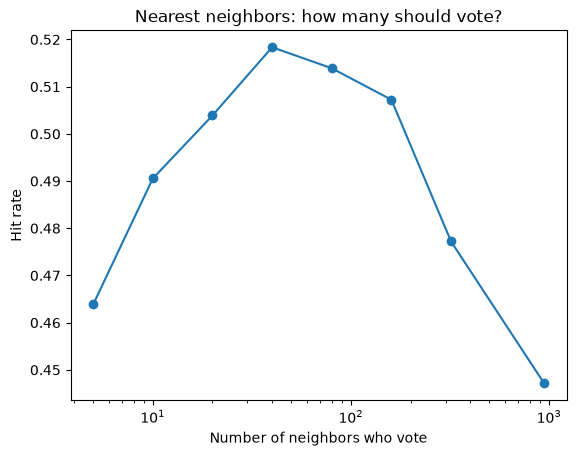

In [13]:
import matplotlib.pyplot as plt

neighbor_counts = [5, 10, 20, 40, 80, 160, 320, 943]
hit_rates = [evaluate(lambda user, k=k: neighbors_reco(user, k)) for k in neighbor_counts]

plt.plot(neighbor_counts, hit_rates, marker="o")
plt.xscale("log")
plt.xlabel("Number of neighbors who vote")
plt.ylabel("Hit rate")
plt.title("Nearest neighbors: how many should vote?")
plt.show()

With too few neighbors, a handful of users decide everything. With too many, the popular films come back. Around 40, we get the best of both.

## Similar films: people who liked this also liked

### a. Let's read the table by column

We can also read the same table the other way around. A column tells us who liked a film: its **audience**. Two films are similar when the same people liked them.

![Psycho and The Birds were liked by the same users, so they are similar; Toy Story has another audience.](images/films_liked_together.svg)

Same tool, same function! We only give it the columns instead of the rows, that is, the transposed table `likes_table.T`:

In [14]:
film_similarities = cosine_similarities(likes_table.T)

for title in ["Psycho (1960)", "Evil Dead II (1987)"]:
    movie = titles.index(title)
    closest = np.argsort(-film_similarities[movie], kind="stable")[1:4]  # skip the film itself
    print(f"{title} -> {[titles[similar] for similar in closest]}")

Psycho (1960) -> ['Rear Window (1954)', 'Birds, The (1963)', 'Silence of the Lambs, The (1991)']
Evil Dead II (1987) -> ['Army of Darkness (1993)', 'Nightmare on Elm Street, A (1984)', 'Braindead (1992)']


Psycho gives Rear Window and The Birds: two other Hitchcock films! Evil Dead II gives Army of Darkness: its sequel. The recommender knows nothing about directors or sequels. The audience told it.

This is the famous "customers who bought this item also bought" of online shops.

### b. Let's recommend similar films

To recommend to a user, each film they liked votes for its similar films. The score of a film is the sum of its similarities with the films the user liked:

In [15]:
def similar_films_reco(user: UserId) -> list[MovieId]:
    return top_10(film_similarities[liked(user)].sum(axis=0), user)

for movie in similar_films_reco(fan):
    print(titles[movie])

Alien (1979)
Shining, The (1980)
Raiders of the Lost Ark (1981)
Aliens (1986)
Empire Strikes Back, The (1980)
Terminator, The (1984)
Usual Suspects, The (1995)
Terminator 2: Judgment Day (1991)
Fugitive, The (1993)
Monty Python and the Holy Grail (1974)


### c. How does this recommender perform?

In [16]:
print(f"Similar films: {evaluate(similar_films_reco):.3f}")

Similar films: 0.491

Almost as good as the nearest neighbors. So why bother?

Because this recommender can explain itself. Each recommendation comes from films the user liked, so we can tell them *why*. Let's find the liked film that voted the most for the first recommendation:

In [17]:
first = similar_films_reco(fan)[0]
reason = liked(fan)[np.argmax(film_similarities[liked(fan), first])]

print(f"{titles[first]}, because you liked {titles[reason]}")

Alien (1979), because you liked Silence of the Lambs, The (1991)


A user trusts a recommendation more when they understand it.

## The weak spot: newcomers

Collaborative filtering only knows who liked what. So what happens with someone, or something, that nobody knows yet?

Remember the new horror comedy of chapter 2, released today. Its column is full of 0s: nobody has liked it yet. No neighbor votes for it, and it is similar to no film. It will never be recommended.

New users have the same problem. A few users of our dataset did not like any film in their history. Let's look at their similarity with everybody else:

In [18]:
newcomers = [int(user) for user in history if likes_table[user].sum() == 0]

print(f"Users without any like: {newcomers}")
print(f"Their best similarity: {user_similarities[newcomers].max():.2f}")

Users without any like: [410, 685, 729, 740]
Their best similarity: 0.00


Zero. They have no neighbors, so nobody can vote for them.

This is the **cold start** problem again, and this time it hits both new users and new films. In chapter 1, the bandit handled new users from their context. In chapter 2, the content handled new films from their genres. That is why real systems mix these approaches.

## In summary

| Recommender | Uses | Hit rate |
|---|---|---|
| Random | nothing | 0.034 |
| Popular | everybody's likes | 0.346 |
| Similar × popular (chapter 2) | genres and likes | 0.364 |
| All users vote | every user, weighted by similarity | 0.447 |
| 40 nearest neighbors | the most similar users | 0.518 |
| Similar films | films with the same audience | 0.491 |

Collaborative filtering recommends from the likes only. Read by row, the likes table tells us who is like you: your nearest neighbors vote for the films they liked. Read by column, it tells us which films share an audience: the films you liked vote for their similar films. No genre needed, and it beats everything we built so far.

But look at what we computed: a similarity for every pair of users, 943 × 943. With millions of users, this table no longer fits anywhere. And the newcomers are left out.

What if, instead, we learned a short vector for every user and every film, from their likes, and also from what we know about them, like their age or their genres? That is the idea of the **two-tower** model, our next chapter.